<a href="https://www.kaggle.com/code/dheriisousa/03-cnns-and-vit?scriptVersionId=325017675" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 99.6 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.2

In [2]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import PathMNIST

# 1. Pipeline de Transformações (Obrigatório para transfer learning)
# O professor exigiu explicitamente: normalização ImageNet e ToTensor.
# A Normalização ImageNet usa as médias e desvios padrões oficiais das imagens reais.
transformacao = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Carregando o Dataset Oficial de 224x224
print("Baixando e preparando o PathMNIST 224x224 (Pode demorar um pouquinho)...")
train_dataset = PathMNIST(split="train", size=224, download=True, transform=transformacao)
val_dataset   = PathMNIST(split="val", size=224, download=True, transform=transformacao)
test_dataset  = PathMNIST(split="test", size=224, download=True, transform=transformacao)

# 3. Criando os DataLoaders (Gerenciadores de Lote Inteligentes)
# Diminuímos o batch_size de 256 para 64, porque 224x224 gasta MUITA VRAM da Placa de Vídeo.
# num_workers=2 faz o processador (CPU) pré-carregar as imagens enquanto a GPU treina.
batch_size = 64 

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# ATENÇÃO: O Test Loader fica isolado! Ele só será chamado no dia final (Regra Metodológica do Professor).
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# 4. Testando o Pipeline e Auditando os Tensores
imagens, rotulos = next(iter(train_loader))

print(f"\n✅ Pipeline Concluído!")
print(f"Formato de um lote de imagens: {imagens.shape}") 
# O esperado é [64, 3, 224, 224] -> [Lote, Canais de Cor, Altura, Largura]
print(f"Formato dos rótulos: {rotulos.shape}")             
# O esperado é [64, 1]

Baixando e preparando o PathMNIST 224x224 (Pode demorar um pouquinho)...


100%|██████████| 12.6G/12.6G [12:46<00:00, 16.5MB/s]



✅ Pipeline Concluído!
Formato de um lote de imagens: torch.Size([64, 3, 224, 224])
Formato dos rótulos: torch.Size([64, 1])


In [3]:
import torch.nn as nn
import torch.nn.functional as F

class CNNAutoral(nn.Module):
    def __init__(self, num_classes=9):
        super(CNNAutoral, self).__init__()
        
        # Extrator de Características (Feature Extractor)
        self.features = nn.Sequential(
            # Bloco Convolucional 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), # Normalização para acelerar o treino
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # Reduz a imagem para 112x112
            
            # Bloco Convolucional 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # Reduz a imagem para 56x56
            
            # Bloco Convolucional 3 (Exigência do Professor)
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # Reduz a imagem para 28x28
        )
        
        # Truque de Mestre: Adaptive Pooling
        # Força a saída a ter o tamanho de 7x7, independentemente da entrada.
        # Isso evita que o Linear layer abaixo fique gigantesco e estoure a VRAM!
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        
        # Classificador (Cabeça da Rede)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.5), # Regularização pedida pelo professor (evita overfit)
            nn.Linear(128 * 7 * 7, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

# Testando se a arquitetura suporta o lote que você acabou de carregar!
modelo_cnn = CNNAutoral()
saida_teste = modelo_cnn(imagens) # Passando aquele lote de 64 imagens do passo anterior

print(f"Arquitetura construída com sucesso!")
print(f"Formato da Saída do Modelo: {saida_teste.shape}") 
# Deve imprimir torch.Size([64, 9]), ou seja, 64 imagens, 9 probabilidades de classes.

Arquitetura construída com sucesso!
Formato da Saída do Modelo: torch.Size([64, 9])


In [4]:
import time
import torch.optim as optim

# 1. Configurando o Dispositivo (Garantindo que vai usar a GPU do Kaggle)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de treinamento: {device.type.upper()}")

# 2. A Função Universal
def treinar_modelo(nome_modelo, modelo, train_loader, val_loader, criterion, optimizer, epocas=10):
    # Envia o modelo para a Memória da Placa de Vídeo
    modelo = modelo.to(device)
    
    # Dicionário para salvar os resultados e plotar os gráficos depois
    historico = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    tempo_inicio = time.time()
    
    for epoca in range(epocas):
        # ===============================
        #       MODO DE TREINAMENTO
        # ===============================
        modelo.train() # Ativa BatchNorm e Dropout
        loss_treino_acumulada = 0.0
        
        for imagens, rotulos in train_loader:
            # Envia os dados para a GPU
            imagens = imagens.to(device)
            # O squeeze() remove dimensões extras indesejadas no tensor de rótulos
            rotulos = rotulos.squeeze().to(device) 
            
            # Zera os gradientes
            optimizer.zero_grad()
            
            # Forward + Cálculo da Loss
            saidas = modelo(imagens)
            loss = criterion(saidas, rotulos)
            
            # Backward + Atualização dos Pesos
            loss.backward()
            optimizer.step()
            
            loss_treino_acumulada += loss.item() * imagens.size(0)
            
        loss_treino_media = loss_treino_acumulada / len(train_loader.dataset)
        
        # ===============================
        #       MODO DE VALIDAÇÃO
        # ===============================
        modelo.eval() # Desativa Dropout e congela estatísticas do BatchNorm
        loss_val_acumulada = 0.0
        acertos = 0
        
        # torch.no_grad() desliga o motor de derivadas para economizar MUITA memória
        with torch.no_grad():
            for imagens, rotulos in val_loader:
                imagens = imagens.to(device)
                rotulos = rotulos.squeeze().to(device)
                
                saidas = modelo(imagens)
                loss = criterion(saidas, rotulos)
                loss_val_acumulada += loss.item() * imagens.size(0)
                
                # Pega o índice da classe com a maior probabilidade
                _, predicoes = torch.max(saidas, dim=1)
                acertos += torch.sum(predicoes == rotulos).item()
                
        loss_val_media = loss_val_acumulada / len(val_loader.dataset)
        acc_val_media = (acertos / len(val_loader.dataset)) * 100
        
        # Salvando as métricas da época
        historico['train_loss'].append(loss_treino_media)
        historico['val_loss'].append(loss_val_media)
        historico['val_acc'].append(acc_val_media)
        
        print(f"Época {epoca+1}/{epocas} | Train Loss: {loss_treino_media:.4f} | Val Loss: {loss_val_media:.4f} | Val Acc: {acc_val_media:.2f}%")
        
    tempo_total = time.time() - tempo_inicio
    print(f"\n✅ Treinamento de '{nome_modelo}' concluído em {tempo_total/60:.2f} minutos!")
    
    return modelo, historico

# 3. Executando o Treinamento da CNN Autoral
# Instanciamos o modelo do zero para garantir que está limpo
modelo_autoral = CNNAutoral()

# O professor pediu para cruzar 2 otimizadores (Ex: SGD vs AdamW). 
# Vamos começar com o poderoso AdamW e uma taxa de aprendizado menor.
criterion = torch.nn.CrossEntropyLoss()
optimizer_autoral = optim.AdamW(modelo_autoral.parameters(), lr=0.001, weight_decay=1e-4)

print("\n--- Iniciando Experimento: CNN Autoral (AdamW) ---")
modelo_autoral_treinado, historico_autoral = treinar_modelo(
    nome_modelo="CNN Autoral - AdamW",
    modelo=modelo_autoral,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_autoral,
    epocas=10 # 10 épocas são um bom começo para ver se a rede tem potencial
)

Dispositivo de treinamento: CUDA

--- Iniciando Experimento: CNN Autoral (AdamW) ---
Época 1/10 | Train Loss: 0.6464 | Val Loss: 0.3365 | Val Acc: 87.21%
Época 2/10 | Train Loss: 0.3658 | Val Loss: 0.3292 | Val Acc: 88.29%
Época 3/10 | Train Loss: 0.2677 | Val Loss: 0.2686 | Val Acc: 90.67%
Época 4/10 | Train Loss: 0.2127 | Val Loss: 0.2148 | Val Acc: 92.80%
Época 5/10 | Train Loss: 0.1836 | Val Loss: 0.2442 | Val Acc: 91.95%
Época 6/10 | Train Loss: 0.1593 | Val Loss: 0.2334 | Val Acc: 92.42%
Época 7/10 | Train Loss: 0.1395 | Val Loss: 0.1593 | Val Acc: 95.47%
Época 8/10 | Train Loss: 0.1267 | Val Loss: 0.1173 | Val Acc: 96.57%
Época 9/10 | Train Loss: 0.1108 | Val Loss: 0.2299 | Val Acc: 93.51%
Época 10/10 | Train Loss: 0.0959 | Val Loss: 0.0853 | Val Acc: 97.50%

✅ Treinamento de 'CNN Autoral - AdamW' concluído em 37.94 minutos!


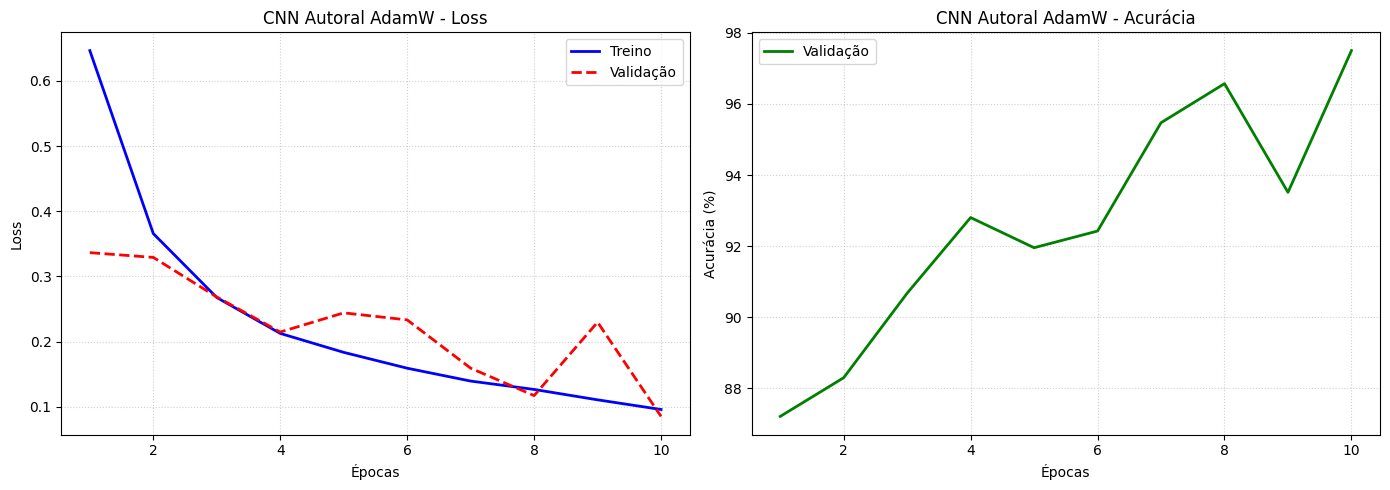

In [5]:
import matplotlib.pyplot as plt

def plotar_historico(historico, titulo="Desempenho do Modelo"):
    epocas = range(1, len(historico['train_loss']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Gráfico de Loss (Perda)
    plt.subplot(1, 2, 1)
    plt.plot(epocas, historico['train_loss'], 'b-', label='Treino', linewidth=2)
    plt.plot(epocas, historico['val_loss'], 'r--', label='Validação', linewidth=2)
    plt.title(f'{titulo} - Loss')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Gráfico de Acurácia
    plt.subplot(1, 2, 2)
    plt.plot(epocas, historico['val_acc'], 'g-', label='Validação', linewidth=2)
    plt.title(f'{titulo} - Acurácia')
    plt.xlabel('Épocas')
    plt.ylabel('Acurácia (%)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    # Salva a imagem para você colocar no PDF depois!
    plt.savefig(f"{titulo.replace(' ', '_').lower()}.png", dpi=300)
    plt.show()

plotar_historico(historico_autoral, titulo="CNN Autoral AdamW")

In [6]:
import torchvision.models as models
import torch.nn as nn

print("--- Preparando ResNet18 (Feature Extraction) ---")

# 1. Baixa o modelo com os pesos mais recentes e eficientes (DEFAULT)
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 2. Congela as camadas convolucionais (O gradiente não vai ser calculado aqui)
for param in resnet.parameters():
    param.requires_grad = False

# 3. Troca a "Cabeça" da rede
# A ResNet18 original cospe 1000 classes. Nosso dataset PathMNIST tem 9.
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 9) 
# Note que a nova camada (resnet.fc) vem com requires_grad=True por padrão!

# 4. Otimizador e Função de Perda
# Como só a última camada vai treinar, passamos apenas os parâmetros dela!
criterion = nn.CrossEntropyLoss()
# Vamos cruzar os otimizadores como o edital pede: usando SGD agora.
optimizer_resnet = torch.optim.SGD(resnet.fc.parameters(), lr=0.01, momentum=0.9)

# O modelo está pronto para ser passado para a nossa função universal!

--- Preparando ResNet18 (Feature Extraction) ---
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:13<00:00, 3.52MB/s]
